<a href="https://colab.research.google.com/github/nyee88/tvam_resin_mini/blob/main/NRC_Postdoc_Project/01_Resin_Discovery_Framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Successfully created 'historical_lab_data.csv' with 100 samples.

Dataset Preview (First 5 Rows):


,Resin_ID,Monomer_Type,Photoinitiator_Perc,Absorber_Perc,Ec_mJ_cm2,Dp_um
0,Resin_001,Acrylate_Standard,2.43,0.183,3.07,171.2
1,Resin_002,Epoxy_Tough,1.98,0.056,7.31,284.7
2,Resin_003,Acrylate_Standard,2.36,0.038,3.52,308.9
3,Resin_004,Acrylate_Standard,2.26,0.103,4.52,239.6
4,Resin_005,Acrylate_Standard,1.58,0.197,6.58,144.2


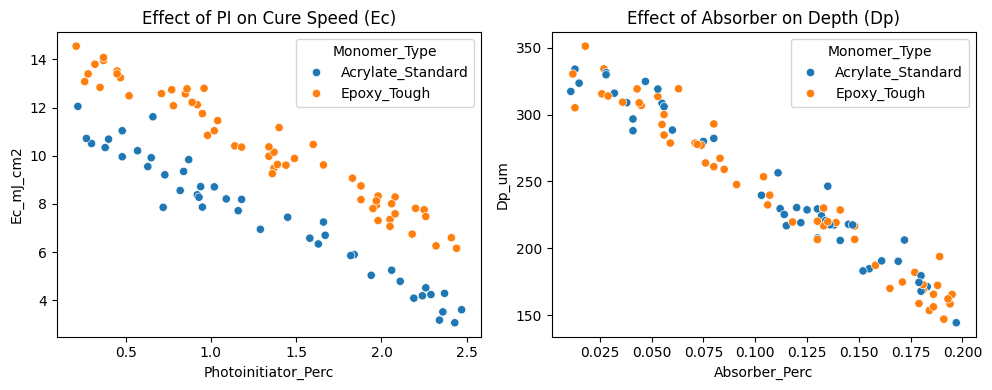

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURATION ---
# We generate the data inside the notebook so it is self-contained.
# This ensures anyone running your portfolio can reproduce your results immediately.
filename = "historical_lab_data.csv"
np.random.seed(42)  # Consistency seed
n_samples = 100      # Small "historical" dataset size

# --- 1. GENERATE INGREDIENTS (The Inputs) ---
data = {
    "Resin_ID": [f"Resin_{i+1:03d}" for i in range(n_samples)],

    # Two common monomer types for 3D printing
    "Monomer_Type": np.random.choice(["Acrylate_Standard", "Epoxy_Tough"], n_samples),

    # Photoinitiator (PI): Drives the reaction. Range: 0.2% to 2.5%
    "Photoinitiator_Perc": np.round(np.random.uniform(0.2, 2.5, n_samples), 2),

    # Absorber: Controls light penetration. Range: 0.01% to 0.2%
    "Absorber_Perc": np.round(np.random.uniform(0.01, 0.2, n_samples), 3),
}

df = pd.DataFrame(data)

# --- 2. SIMULATE PHYSICS PROPERTIES (The Outputs) ---
# We use "Ground Truth" chemical logic so the model learns real relationships.

# Logic for Critical Energy (Ec):
# - More PI = Faster Cure (Lower Ec)
# - Epoxies are generally slower (Higher Ec) than Acrylates
def calc_ec(row):
    base_ec = 12.0
    chem_factor = 3.0 if row["Monomer_Type"] == "Epoxy_Tough" else 0.0
    pi_effect = -3.5 * row["Photoinitiator_Perc"] # More PI lowers Ec
    noise = np.random.normal(0, 0.5)
    return max(1.5, base_ec + chem_factor + pi_effect + noise)

# Logic for Penetration Depth (Dp):
# - More Absorber = Shallower Depth (Lower Dp)
# - Dp follows a logarithmic decay law (Beer-Lambert Law approximation)
def calc_dp(row):
    base_dp = 350.0
    # Strong inverse effect of absorber
    abs_effect = -1000.0 * row["Absorber_Perc"]
    noise = np.random.normal(0, 15)
    return max(50.0, base_dp + abs_effect + noise)

df["Ec_mJ_cm2"] = df.apply(calc_ec, axis=1).round(2)
df["Dp_um"] = df.apply(calc_dp, axis=1).round(1)

# --- 3. SAVE TO CSV (Virtual) ---
df.to_csv(filename, index=False)

print(f"✅ Successfully created '{filename}' with {n_samples} samples.")
print("\nDataset Preview (First 5 Rows):")
display(df.head())

# Optional: Quick visual check
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x="Photoinitiator_Perc", y="Ec_mJ_cm2", hue="Monomer_Type")
plt.title("Effect of PI on Cure Speed (Ec)")

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x="Absorber_Perc", y="Dp_um", hue="Monomer_Type")
plt.title("Effect of Absorber on Depth (Dp)")
plt.tight_layout()
plt.show()

In [17]:
# --- CELL 2: LEARN PHYSICS FROM CHEMISTRY (WITH HELD-OUT TEST SET) ---

# Goal:
#   1) Load the synthetic "historical" resin data
#   2) Train ML models to predict Ec and Dp from chemistry inputs
#   3) Evaluate on a held-out test set (so we don't just fit the noise)
#   4) Define a helper that proposes new formulations for a target Ec/Dp

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
import numpy as np

# 1. Load the "historical" data generated in Cell 1
filename = "historical_lab_data.csv"
df = pd.read_csv(filename)

print(f"Loaded {len(df)} historical resin experiments from '{filename}'")
display(df.head())

# 2. Prepare features (chemistry) and targets (physics)
#    - Inputs: Monomer_Type (categorical), Photoinitiator_Perc, Absorber_Perc
#    - Outputs: Ec_mJ_cm2 (cure speed), Dp_um (penetration depth)

feature_cols = ["Monomer_Type", "Photoinitiator_Perc", "Absorber_Perc"]
X_raw = df[feature_cols]

# One-hot encode monomer family; drop_first=True to avoid redundant column
X_encoded = pd.get_dummies(
    X_raw,
    columns=["Monomer_Type"],
    drop_first=True
)
feature_names = X_encoded.columns.tolist()

X = X_encoded.values
y_ec = df["Ec_mJ_cm2"].values
y_dp = df["Dp_um"].values

print("\nFeature matrix columns used by the ML models:")
print(feature_names)

# 3. Train/test split so we can measure generalization
#    With n=20 this is still a tiny dataset, but the pattern is correct.
X_train, X_test, y_ec_train, y_ec_test, y_dp_train, y_dp_test = train_test_split(
    X, y_ec, y_dp,
    test_size=0.25,
    random_state=42
)

print(f"\nTrain size: {X_train.shape[0]} samples")
print(f"Test size : {X_test.shape[0]} samples")

# 4. Train separate models for Ec and Dp on the same train split
model_ec = RandomForestRegressor(n_estimators=100, random_state=42)
model_dp = RandomForestRegressor(n_estimators=100, random_state=42)

model_ec.fit(X_train, y_ec_train)
model_dp.fit(X_train, y_dp_train)

# 5. Evaluate on the held-out test set
y_ec_pred_test = model_ec.predict(X_test)
y_dp_pred_test = model_dp.predict(X_test)

print("\nModel performance on held-out TEST set:")
print(f"   - Ec  R²: {r2_score(y_ec_test, y_ec_pred_test):.3f}   "
      f"MAE: {mean_absolute_error(y_ec_test, y_ec_pred_test):.2f} mJ/cm²")
print(f"   - Dp  R²: {r2_score(y_dp_test, y_dp_pred_test):.3f}   "
      f"MAE: {mean_absolute_error(y_dp_test, y_dp_pred_test):.1f} µm")

# 6. Helper: search a "virtual" library of candidate formulations
#    and pick the one whose predicted Ec/Dp are closest to a target.

def suggest_formulation(target_ec, target_dp, virtual_samples=5000):
    """
    Search a random virtual library of formulations and return the one
    whose predicted Ec/Dp are closest (in normalized error) to the target.

    target_ec, target_dp : desired cure energy and penetration depth
    virtual_samples      : how many random formulations to explore
    """

    # Use the observed ranges from the historical data as bounds
    pi_min, pi_max = df["Photoinitiator_Perc"].min(), df["Photoinitiator_Perc"].max()
    abs_min, abs_max = df["Absorber_Perc"].min(), df["Absorber_Perc"].max()

    # Build a virtual library
    virtual_df = pd.DataFrame({
        "Photoinitiator_Perc": np.random.uniform(pi_min, pi_max, virtual_samples),
        "Absorber_Perc":      np.random.uniform(abs_min, abs_max, virtual_samples),
        # One-hot column must match the encoded training data
        "Monomer_Type_Epoxy_Tough": np.random.choice([0, 1], size=virtual_samples),
    })

    # Order columns to match the feature matrix used during training
    X_virtual = virtual_df[feature_names].values

    # Predict Ec and Dp for each virtual formulation
    virtual_df["Pred_Ec"] = model_ec.predict(X_virtual)
    virtual_df["Pred_Dp"] = model_dp.predict(X_virtual)

    # Normalized error relative to the target (simple 2D distance)
    eps = 1e-6
    ec_scale = max(abs(target_ec), eps)
    dp_scale = max(abs(target_dp), eps)

    virtual_df["Error"] = np.sqrt(
        ((virtual_df["Pred_Ec"] - target_ec) / ec_scale) ** 2 +
        ((virtual_df["Pred_Dp"] - target_dp) / dp_scale) ** 2
    )

    # Pick the best candidate
    best_match = virtual_df.sort_values("Error").iloc[0]

    monomer_name = (
        "Epoxy_Tough"
        if best_match["Monomer_Type_Epoxy_Tough"] == 1
        else "Acrylate_Standard"
    )

    print(f"\n🧪 AI Recommendation for Target (Ec={target_ec}, Dp={target_dp}):")
    print(f"   - Monomer:         {monomer_name}")
    print(f"   - Photoinitiator:  {best_match['Photoinitiator_Perc']:.2f}%")
    print(f"   - Absorber:        {best_match['Absorber_Perc']:.3f}%")
    print(f"   - Predicted Ec:    {best_match['Pred_Ec']:.2f} mJ/cm²")
    print(f"   - Predicted Dp:    {best_match['Pred_Dp']:.1f} µm")

    return best_match




Loaded 100 historical resin experiments from 'historical_lab_data.csv'


,Resin_ID,Monomer_Type,Photoinitiator_Perc,Absorber_Perc,Ec_mJ_cm2,Dp_um
0,Resin_001,Acrylate_Standard,2.43,0.183,3.07,171.2
1,Resin_002,Epoxy_Tough,1.98,0.056,7.31,284.7
2,Resin_003,Acrylate_Standard,2.36,0.038,3.52,308.9
3,Resin_004,Acrylate_Standard,2.26,0.103,4.52,239.6
4,Resin_005,Acrylate_Standard,1.58,0.197,6.58,144.2



Feature matrix columns used by the ML models:
['Photoinitiator_Perc', 'Absorber_Perc', 'Monomer_Type_Epoxy_Tough']

Train size: 75 samples
Test size : 25 samples

Model performance on held-out TEST set:
   - Ec  R²: 0.946   MAE: 0.56 mJ/cm²
   - Dp  R²: 0.934   MAE: 11.3 µm


In [18]:
# --- CELL 3: USE THE MODEL TO PROPOSE A FORMULATION & CHECK AGAINST GROUND TRUTH ---

# 1. Ask the model for a resin that meets our target Ec and Dp
target_ec = 8.0
target_dp = 175.0

best = suggest_formulation(
    target_ec=target_ec,
    target_dp=target_dp,
    virtual_samples=5000
)

# 2. Recover the monomer family from the one-hot column
monomer_name = (
    "Epoxy_Tough"
    if best["Monomer_Type_Epoxy_Tough"] == 1
    else "Acrylate_Standard"
)

# 3. Compare model prediction to the "true" Ec/Dp from the synthetic physics model

# Build a row-like object with the same keys used in calc_ec / calc_dp
row = {
    "Monomer_Type": monomer_name,
    "Photoinitiator_Perc": float(best["Photoinitiator_Perc"]),
    "Absorber_Perc": float(best["Absorber_Perc"]),
}

true_ec = calc_ec(row)
true_dp = calc_dp(row)

print("\nGround-truth check using the underlying physics model:")
print(f"   - Monomer:             {monomer_name}")
print(f"   - PI % / Absorber %:   {best['Photoinitiator_Perc']:.2f} / {best['Absorber_Perc']:.3f}")
print(f"   - Target Ec / Dp:      {target_ec:.2f} mJ/cm² / {target_dp:.1f} µm")
print(f"   - Model-pred Ec / Dp:  {best['Pred_Ec']:.2f} mJ/cm² / {best['Pred_Dp']:.1f} µm")
print(f"   - True Ec / Dp:        {true_ec:.2f} mJ/cm² / {true_dp:.1f} µm")



🧪 AI Recommendation for Target (Ec=8.0, Dp=175.0):
   - Monomer:         Epoxy_Tough
   - Photoinitiator:  2.16%
   - Absorber:        0.162%
   - Predicted Ec:    7.98 mJ/cm²
   - Predicted Dp:    176.8 µm


TypeError: calc_ec() got an unexpected keyword argument 'monomer_type'